# MCQMC 2026 Plenary Talk Running Example

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vf}{\boldsymbol{f}}
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vu}{\boldsymbol{u}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vy}{\boldsymbol{y}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vmu}{\boldsymbol{\mu}}
\newcommand{\mSigma}{\mathsf{\Sigma}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Order}{\mathcal{O}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\Norm}{\operatorname{Norm}}
\newcommand{\GP}{\operatorname{GP}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

We observe noisy function values

$$
Y_i = f(x_i) + \epsilon_i, \qquad 
\epsilon_i \sim \Norm(0,\sigma^2),
\qquad i=1,\ldots,m,
$$

and place a Gaussian process prior on the unknown function,

$$
f \sim \GP(0,K_\theta).
$$

Because the prior and likelihood are Gaussian, the posterior distribution of the vector of latent function values on a grid,

$$
\vf =
\bigl(f(t_1),\ldots,f(t_d)\bigr)^\top,
$$

obeys a multivariate normal,

$$
\vf \mid \vy
\sim
\Norm(\vmu,\mSigma).
$$

The quantity of interest is the posterior probability that the latent function remains below a safety threshold $c$ on the grid:

$$
p
=
\Pr\{ f(t_j) \le c,\ j=1,\ldots,d \mid \vy \}
=
\int_{\mathbb{R}^d}
\mathbb{1}\{\vz \le c\mathbf{1}\}
\,
\phi_d(\vz;\vmu,\mSigma)
\,\dif \vz.
$$

After a transformation from independent uniforms to the posterior Gaussian vector, this becomes an integral over the unit cube,

$$
p
=
\int_{[0,1]^d}
g(\vu)\,\dif \vu.
$$

This single example lets us compare Monte Carlo and quasi-Monte Carlo sampling, study the effect of variable transformations, test randomized error estimation, and later consider refinements such as multilevel or dimension-reduction strategies.

## Imports

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import qmcpy as qp
import time
import pandas as pd
from IPython.display import display, Markdown

import classlib as cl
import classlib.nbviz as nb

from qmcpy.util import MaxSamplesWarning
import warnings

%matplotlib inline

rng_seed = 20260527
rng = np.random.default_rng(rng_seed)

nb.init(use_tex=True)
colors = nb.TOL_BRIGHT

# nb.SAVEFIGS = False;


## Notebook parameters

In [5]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

DATA_DIR = NOTEBOOK_DIR / "data"
GENVEC_DIR = DATA_DIR / "generating_vectors"

CACHE_DIR = NOTEBOOK_DIR / "cache"
CACHE_BENCHMARK_DIR = CACHE_DIR / "benchmarks"
CACHE_FIGURE_DIR = CACHE_DIR / "figures"
CACHE_TABLE_DIR = CACHE_DIR / "tables"

ARTIFACT_DIR = NOTEBOOK_DIR / "artifacts"
ARTIFACT_BENCHMARK_DIR = ARTIFACT_DIR / "benchmarks"
ARTIFACT_FIGURE_DIR = ARTIFACT_DIR / "figures"
ARTIFACT_TABLE_DIR = ARTIFACT_DIR / "tables"

CACHE_BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TABLE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

nb.configure(
    figpath=str(CACHE_FIGURE_DIR),
    savefigs=True,
    imgfrmt="png",
)


In [189]:
run_sims = True

benchmark_files = {
    "pca": ARTIFACT_BENCHMARK_DIR / "running_pca_n16384_reps100.pkl",
    "chol": ARTIFACT_BENCHMARK_DIR / "running_chol_n16384_reps100.pkl",
}

rng_seed = 20260527

n_obs = 9 #number of observations of the function, i.e., where the data is taken
d_grid = 64 #number of evaluation points along the line, i.e., where I need the function to be under the threshold
d_plot = 512 #number of points to plot

sigma_noise = 0.15 #standard deviation of noise in the observations
jitter = 1e-10 #to avoid ill-conditioning

threshold = 2.0        # threshold acts pointwise: penalize g(t) > threshold


# Synthetic data and Gaussian process posterior

In [190]:
rng = np.random.default_rng(rng_seed)

def f_true(x):
    return (
        -1.5
        + 1.0 * np.cos(2 * np.pi*x)
        + 3.5 * np.sin(2 * np.pi * x)
        + 2.2 * np.cos(6 * np.pi * x)
        + 1.2 * np.sin(10 * np.pi * x)
    )

def sqexp_kernel(x, z, amp=10.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    return amp**2 * np.exp(-0.5 * ((x - z) / ell)**2)

def matern52_kernel(x, z, amp=10.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt5r = np.sqrt(5) * r
    return amp**2 * (1 + sqrt5r + 5 * r**2 / 3) * np.exp(-sqrt5r)

def matern32_kernel(x, z, amp=10.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt3r = np.sqrt(3) * r
    return amp**2 * (1 + sqrt3r) * np.exp(-sqrt3r)

kernel = matern32_kernel

x_obs = np.linspace(0.08, 0.92, n_obs)
y_obs = f_true(x_obs) + sigma_noise * rng.standard_normal(n_obs)

t_grid = np.linspace(0, 1, d_grid)

K_xx = kernel(x_obs, x_obs)
K_tx = kernel(t_grid, x_obs)
K_tt = kernel(t_grid, t_grid)

A = K_xx + sigma_noise**2 * np.eye(n_obs)
L_A = np.linalg.cholesky(A + jitter * np.eye(n_obs))

alpha = np.linalg.solve(L_A.T, np.linalg.solve(L_A, y_obs))
post_mean = K_tx @ alpha

V = np.linalg.solve(L_A, K_tx.T)
post_cov = K_tt - V.T @ V
post_cov = 0.5 * (post_cov + post_cov.T)

L_post = np.linalg.cholesky(post_cov + jitter * np.eye(d_grid))

t_plot = np.linspace(0, 1, d_plot)

K_px = kernel(t_plot, x_obs)
K_pp = kernel(t_plot, t_plot)

post_mean_plot = K_px @ alpha

V_plot = np.linalg.solve(L_A, K_px.T)
post_cov_plot = K_pp - V_plot.T @ V_plot
post_cov_plot = 0.5 * (post_cov_plot + post_cov_plot.T)

post_sd_plot = np.sqrt(np.maximum(np.diag(post_cov_plot), 0))

# Plot posterior mean and pointwise credible band

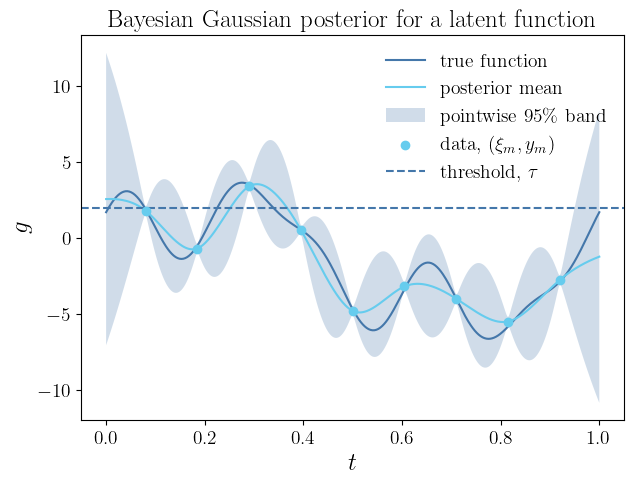

In [191]:
post_sd = np.sqrt(np.diag(post_cov))

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(t_plot, f_true(t_plot), label="true function")
ax.plot(t_plot, post_mean_plot, label="posterior mean")
ax.fill_between(
    t_plot,
    post_mean_plot - 1.96 * post_sd_plot,
    post_mean_plot + 1.96 * post_sd_plot,
    alpha=0.25,
    label="pointwise 95\% band",
)
ax.scatter(x_obs, y_obs, zorder=5, label=r"data, $(\xi_m, y_m)$")
ax.axhline(threshold, linestyle="--", label=r"threshold, $\tau$")

ax.set_xlabel("$t$")
ax.set_ylabel("$g$")
ax.set_title("Bayesian Gaussian posterior for a latent function")
ax.legend(loc="best")

if nb.SAVEFIGS:
    nb.savefig("posterior_gp_example")
plt.show()

# Quantity of interest: posterior probability that the curve is not far above the threshold

## Sequences

In [9]:
kron_vec = np.loadtxt(
    GENVEC_DIR / "kron_vector_d-100_N-2exp20_2026_06_01.txt"
)

def make_sequences(default_dimension=d_grid):
    return {
        "iid": {
            "label": "IID",
            "distribution": lambda reps=None, dimension=default_dimension: qp.IIDStdUniform(
                dimension,
                replications=reps,
            ),
            "color": colors["blue"],
            "linestyle": "-",
            "alpha": 0.12,
        },
        "sobol": {
            "label": "Sobol'",
            "distribution": lambda reps=None, dimension=default_dimension: qp.Sobol(
                dimension,
                randomize=True,
                replications=reps,
            ),
            "color": colors["green"],
            "linestyle": "--",
            "alpha": 0.22,
        },
        "lattice": {
            "label": "Lattice",
            "distribution": lambda reps=None, dimension=default_dimension: qp.Lattice(
                dimension,
                randomize=True,
                replications=reps,
            ),
            "color": colors["red"],
            "linestyle": "-.",
            "alpha": 0.18,
        },
        "halton": {
            "label": "Halton",
            "distribution": lambda reps=None, dimension=default_dimension: qp.Halton(
                dimension,
                randomize=True,
                replications=reps,
            ),
            "color": colors["purple"],
            "linestyle": ":",
            "alpha": 0.18,
        },
        "kronecker": {
            "label": "Kronecker",
            "distribution": lambda reps=None, dimension=default_dimension: qp.Kronecker(
                dimension,
                randomize=True,
                replications=reps,
                generating_vector=kron_vec[:dimension],
            ),
            "color": colors["yellow"],
            "linestyle": (0, (3, 1, 1, 1)),
            "alpha": 0.25,
        },
    }

sequences = make_sequences()

## Make posterior measure

In [10]:
def make_posterior_measure(distribution, decomp_type="PCA"):
    return qp.Gaussian(
        distribution,
        mean=post_mean,
        covariance=post_cov,
        decomp_type=decomp_type,   # "PCA" or "Cholesky"
    )

## Integrand loss and penalty function

In [11]:
def local_loss_hard(g):
    return np.maximum(g - threshold, 0.0)**2


def smooth_positive_part(z, eta=0.05):
    return eta * np.logaddexp(0.0, z / eta)


def local_loss_smooth(g, eta=0.05):
    return smooth_positive_part(g - threshold, eta=eta)**2

def spatial_risk_hard(f_samples):
    return np.trapezoid(local_loss_hard(f_samples), x=t_grid, axis=-1)


def spatial_risk_smooth(f_samples, eta=0.05):
    return np.trapezoid(local_loss_smooth(f_samples, eta=eta), x=t_grid, axis=-1)


def risk_integrand_g_hard(f_samples):
    J = spatial_risk_hard(f_samples)
    return J**2


def risk_integrand_g_smooth(f_samples):
    J = spatial_risk_smooth(f_samples, eta=0.05)
    return J**2

def linear_functional_integrand(f_samples):
    J = np.trapezoid(f_samples, x=t_grid, axis=-1)
    return J

integrands = {
    "risk_qoi": {
        "label": "Risk QOI, hard threshold",
        "integrand": risk_integrand_g_hard,
    },
    "risk_qoi_smooth": {
        "label": "Risk QOI, smooth threshold",
        "integrand": risk_integrand_g_smooth,
    },
}

integrands["linear_functional"] = {
    "label": "Linear functional",
    "integrand": linear_functional_integrand,
}

## Beginning of the transforms dictionary

In [12]:
transforms = {
    "chol": {
        "label": "Cholesky",
        "decomp_type": "Cholesky",
        "savefig_suffix": "chol",
    },
    "pca": {
        "label": "PCA",
        "decomp_type": "PCA",
        "savefig_suffix": "pca",
    },
}

## First direct integrand Monte Carlo and Sobol' checks

In [13]:
def check_transform_estimates(integrand_key, transform_key, n=2**12, d_grid=d_grid):
    transform = transforms[transform_key]
    integrand_info = integrands[integrand_key]
    integrand = integrand_info["integrand"]
    decomp_type = transform["decomp_type"]

    iid_measure = make_posterior_measure(
        sequences["iid"]["distribution"](),
        decomp_type=decomp_type,
    )

    vals = np.asarray(integrand(iid_measure(n))).reshape(-1)
    mc_sol = vals.mean()
    mc_err = 1.96 * vals.std(ddof=1) / math.sqrt(vals.size)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", MaxSamplesWarning)

        sobol_g_measure = make_posterior_measure(
            sequences["sobol"]["distribution"](),
            decomp_type=decomp_type,
        )

        sobol_g_sol, sobol_g_data = qp.CubQMCNetG(
            qp.CustomFun(
                sobol_g_measure,
                integrand,
            ),
            abs_tol=1e-12,
            n_init=n,
            n_limit=n,
        ).integrate()

        clt_rep = 2**4

        sobol_clt_base = qp.Sobol(
            d_grid,
            randomize=True,
            replications=clt_rep,
        )

        sobol_clt_measure = make_posterior_measure(
            sequences["sobol"]["distribution"](reps=clt_rep),
            decomp_type=decomp_type,
        )

        sobol_clt_sol, sobol_clt_data = qp.CubQMCRepStudentT(
            qp.CustomFun(
                sobol_clt_measure,
                integrand,
            ),
            abs_tol=1e-12,
            n_init=n // clt_rep,
            n_limit=n,
        ).integrate()

    sobol_g_err = sobol_g_data.comb_bound_diff / 2
    sobol_clt_err = sobol_clt_data.comb_bound_diff / 2

    message = (
        f"For {integrand_info['label']}, {transform['label']}\n"
        f"Based on n = {n} samples and d = {d_grid} discretization\n"
        f"IID MC:  {mc_sol:.5f} +/- {mc_err:.5f}\n"
        f"Sobol' G:  {sobol_g_sol:.5f} +/- {sobol_g_err:.5f}  "
        f"(CubQMCNetG bound)\n"
        f"Sobol' CLT:  {sobol_clt_sol:.5f} +/- {sobol_clt_err:.5f} "
        f"(CubQMCRepStudentT bound,  {n // clt_rep} samples, {clt_rep} replications)"
    )
    
    results = {
        "integrand": integrand_info["label"],
        "transform": transform["label"],
        "n": n,
        "message": message,
        "mc_sol": mc_sol,
        "mc_err": mc_err,
        "sobol_g_sol": sobol_g_sol,
        "sobol_g_err": sobol_g_err,
        "sobol_g_data": sobol_g_data,
        "sobol_clt_sol": sobol_clt_sol,
        "sobol_clt_err": sobol_clt_err,
        "sobol_clt_data": sobol_clt_data,
    }

    transforms[transform_key]["check"] = results  

    return results

integrand_key = "risk_qoi"
transform_key = "pca"
check_transform_estimates(integrand_key,transform_key)
print(transforms[transform_key]["check"]["message"]) 

For Risk QOI, hard threshold, PCA
Based on n = 4096 samples and d = 64 discretization
IID MC:  1.84342 +/- 0.16058
Sobol' G:  1.73505 +/- 0.01879  (CubQMCNetG bound)
Sobol' CLT:  1.76223 +/- 0.07734 (CubQMCRepStudentT bound,  256 samples, 16 replications)


In [14]:
transform_key = "chol"
check_transform_estimates(integrand_key, transform_key)
print(transforms[transform_key]["check"]["message"]) 

For Risk QOI, hard threshold, Cholesky
Based on n = 4096 samples and d = 64 discretization
IID MC:  1.65857 +/- 0.14781
Sobol' G:  1.74286 +/- 0.01639  (CubQMCNetG bound)
Sobol' CLT:  1.71130 +/- 0.05877 (CubQMCRepStudentT bound,  256 samples, 16 replications)


## Randomized replicate comparison: MC versus QMC

### Initial parameters

In [15]:
r = 100 #number of replications
fill_hw_default = 0.25 #half-width of band

### Means, standard deviation, and plots helpers

In [16]:
def replicate_running_means(sequence, integrand, transform, n, reps=r):
    measure = make_posterior_measure(
        sequence["distribution"](reps=reps),
        decomp_type=transform["decomp_type"],
    )
    
    x = measure(n)
    
    if x.ndim == 2:
        x = x.reshape(1, *x.shape)

    r_actual, n_actual, d_actual = x.shape
    assert d_actual == d_grid

    vals = integrand(
        x.reshape(r_actual * n_actual, -1)
    )
    vals = np.asarray(vals).reshape(r_actual, n_actual)

    return np.cumsum(vals, axis=1) / np.arange(1, n_actual + 1)

def plot_running_band(
    ax,
    running,
    label=None,
    color=None,
    fill_hw=fill_hw_default,
    linestyle="-",
    linewidth=2,
    alpha=0.18,
    n_min_plot=100,
):
    k = np.arange(1, running.shape[1] + 1)
    mask = k >= n_min_plot

    center = running.mean(axis=0)
    qlo = np.quantile(running, 0.5-fill_hw, axis=0)
    qup = np.quantile(running, 0.5+fill_hw, axis=0)

    ax.plot(
        k[mask],
        center[mask],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
    )

    ax.fill_between(
        k[mask],
        qlo[mask],
        qup[mask],
        color=color,
        alpha=alpha,
    )

def plot_running_sequences(
    running,
    sequences,
    title="Running estimates across randomized replicates",
    ylabel=r"$\widehat{\mu}_{n}$",
    n_min_plot=100,
    fill_hw=fill_hw_default,
    figsize=(7, 5),
    savefig=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    for key, sequence in sequences.items():
        plot_running_band(
            ax,
            running[key],
            label=sequence["label"],
            color=sequence["color"],
            linestyle=sequence["linestyle"],
            alpha=sequence["alpha"],
            n_min_plot=n_min_plot,
            fill_hw=fill_hw,
        )

    n_max_plot = next(iter(running.values())).shape[1]

    ax.set_xscale("log")
    xticks = 2**np.arange(6, 20)
    xticks = xticks[(xticks >= n_min_plot) & (xticks <= n_max_plot)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x}" for x in xticks])

    ax.set_xlim(left=n_min_plot, right=n_max_plot)
    ax.set_xlabel(r"number of samples, $n$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best")

    if savefig is not None and nb.SAVEFIGS:
        nb.savefig(savefig)

    plt.show()

def fit_power_trend(n_grid, sd_values, trend_n_min):
    trend_mask = (
        (n_grid >= trend_n_min)
        & np.isfinite(sd_values)
        & (sd_values > 0)
    )
    slope, intercept = np.polyfit(
        np.log(n_grid[trend_mask]),
        np.log(sd_values[trend_mask]),
        deg=1,
    )
    return slope, intercept
    
def compute_sd_slopes(running, exact_mean, n_min=100):
    """
    Return all-n and power-of-2 slopes for SD across randomizations.

    The running array has shape (reps, n).
    """
    err = running - exact_mean
    sd_by_n = err.std(axis=0, ddof=1)

    n_grid = np.arange(1, len(sd_by_n) + 1)

    all_mask = (
        (n_grid >= n_min)
        & np.isfinite(sd_by_n)
        & (sd_by_n > 0)
    )

    slope_all, intercept_all = np.polyfit(
        np.log(n_grid[all_mask]),
        np.log(sd_by_n[all_mask]),
        deg=1,
    )

    powers = 2 ** np.arange(
        int(np.ceil(np.log2(n_min))),
        int(np.floor(np.log2(len(sd_by_n)))) + 1,
    )

    pow2_mask = (
        np.isfinite(sd_by_n[powers - 1])
        & (sd_by_n[powers - 1] > 0)
    )

    slope_pow2, intercept_pow2 = np.polyfit(
        np.log(powers[pow2_mask]),
        np.log(sd_by_n[powers[pow2_mask] - 1]),
        deg=1,
    )

    return {
        "slope_all": slope_all,
        "intercept_all": intercept_all,
        "slope_pow2": slope_pow2,
        "intercept_pow2": intercept_pow2,
        "sd_by_n": sd_by_n,
    }


def compute_sd_slope(running, exact_mean, n=None, k_min=4):
    """
    Backward-compatible helper.

    Fits only powers of 2, matching the original simple-example code.
    """
    if n is None:
        n = running.shape[1]

    n_min = 2**k_min
    slopes = compute_sd_slopes(
        running=running[:, :n],
        exact_mean=exact_mean,
        n_min=n_min,
    )

    return slopes["slope_pow2"], slopes["sd_by_n"]

def plot_running_sd_vs_n(
    running,
    sequences,
    title="Standard deviation across randomized replicates",
    ylabel=r"sample standard deviation",
    n_min_plot=100,
    trend_n_min=None,
    iid_key="iid",
    figsize=(7, 5),
    savefig=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    n_max_plot = next(iter(running.values())).shape[1]
    n_grid = np.arange(1, n_max_plot + 1)

    powers = 2 ** np.arange(0, int(np.floor(np.log2(n_max_plot))) + 1)
    powers = powers[(powers >= n_min_plot) & (powers <= n_max_plot)]

    if trend_n_min is None:
        trend_n_min = n_min_plot

    sd_by_key = {}

    for key, sequence in sequences.items():
        sd_running = np.std(running[key], axis=0, ddof=1)
        sd_by_key[key] = sd_running

        mask = n_grid >= n_min_plot

        ax.plot(
            n_grid[mask],
            sd_running[mask],
            label=sequence["label"],
            color=sequence["color"],
            linestyle=sequence["linestyle"],
            linewidth=2,
        )

        ax.plot(
            powers,
            sd_running[powers - 1],
            marker="o",
            linestyle="none",
            color=sequence["color"],
            markersize=5,
        )

    mask = n_grid >= n_min_plot

    if iid_key in sd_by_key:
        iid_slope, iid_intercept = fit_power_trend(
            n_grid,
            sd_by_key[iid_key],
            trend_n_min,
        )
        iid_trend = np.exp(iid_intercept) * n_grid[mask] ** iid_slope
        iid_color = sequences[iid_key]["color"]

        ax.plot(
            n_grid[mask],
            iid_trend,
            color=iid_color,
            linestyle="-",
            linewidth=4,
            alpha=0.35,
            label=rf"IID trend, $n^{{{iid_slope:.2f}}}$",
        )
    
    qmc_keys = [key for key in sequences if key != iid_key]
    if len(qmc_keys) == 1:
        qmc_label = sequences[qmc_keys[0]]["label"]
    else:
        qmc_label = "Low-discrepancy"

    if qmc_keys:
        log_n_list = []
        log_sd_list = []

        for key in qmc_keys:
            sd_running = sd_by_key[key]
            trend_mask = (
                (n_grid >= trend_n_min)
                & np.isfinite(sd_running)
                & (sd_running > 0)
            )
            log_n_list.append(np.log(n_grid[trend_mask]))
            log_sd_list.append(np.log(sd_running[trend_mask]))

        qmc_slope, qmc_intercept = np.polyfit(
            np.concatenate(log_n_list),
            np.concatenate(log_sd_list),
            deg=1,
        )

        qmc_trend = np.exp(qmc_intercept) * n_grid[mask] ** qmc_slope

        ax.plot(
            n_grid[mask],
            qmc_trend,
            color="black",
            linestyle="--",
            linewidth=4,
            alpha=0.45,
            label=rf"{qmc_label} all-n trend, $n^{{{qmc_slope:.2f}}}$",
        )

    sobol_lattice_keys = [
        key for key in ["sobol", "lattice"]
        if key in sd_by_key and key in sequences
    ]
    
    if sobol_lattice_keys:
        log_n_list = []
        log_sd_list = []
    
        for key in sobol_lattice_keys:
            sd_running = sd_by_key[key]
    
            power_mask = np.isin(n_grid, powers)
    
            trend_mask = (
                (n_grid >= trend_n_min)
                & power_mask
                & np.isfinite(sd_running)
                & (sd_running > 0)
            )
    
            log_n_list.append(np.log(n_grid[trend_mask]))
            log_sd_list.append(np.log(sd_running[trend_mask]))
    
        sl_qmc_slope, sl_qmc_intercept = np.polyfit(
            np.concatenate(log_n_list),
            np.concatenate(log_sd_list),
            deg=1,
        )
    
        sl_qmc_trend = np.exp(sl_qmc_intercept) * n_grid[mask] ** sl_qmc_slope
    
        sl_label = "/".join(
            sequences[key]["label"]
            for key in sobol_lattice_keys
        )
    
        ax.plot(
            n_grid[mask],
            sl_qmc_trend,
            color="gray",
            linestyle="-.",
            linewidth=4,
            alpha=0.55,
            label=rf"{sl_label} $n$ a power-of-2 trend, $n^{{{sl_qmc_slope:.2f}}}$",
        )
    
    ax.set_xscale("log")
    ax.set_yscale("log")

    xticks = 2 ** np.arange(6, 20)
    xticks = xticks[(xticks >= n_min_plot) & (xticks <= n_max_plot)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x}" for x in xticks])

    ax.set_xlim(left=n_min_plot, right=n_max_plot)
    ax.set_xlabel(r"number of samples, $n$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="lower left")

    if savefig is not None and nb.SAVEFIGS:
        nb.savefig(savefig)

    plt.show()
    
def summarize_running(running, sequences, integrand, transform):
    iid_key = next(
        key for key, sequence in sequences.items()
        if "IID" in sequence["label"]
    )

    iid_sd = running[iid_key][:, -1].std(ddof=1)
    label = transform["label"]

    rows = []

    for key, sequence in sequences.items():
        final_sd = running[key][:, -1].std(ddof=1)

        rows.append({
            "Sequence": sequence["label"],
            rf"{label} std($\widehat{{\mu}}_n$)": final_sd,
            f"{label} std($\widehat{{\mu}}_n$) / IID std($\widehat{{\mu}}_n$)": final_sd / iid_sd,
        })

    return pd.DataFrame(rows)

def write_summary_table(
    summary,
    transform_key,
    sequence_suffix,
    n=None,
):
    filename = f"summary_{transform_key}_{sequence_suffix}.md"

    summary_md = summary.to_markdown(
        index=False,
        floatfmt=("", ".3g", ".3f"),
    )

    header = ""
    if n is not None:
        header = (
            f"<div style='text-align:center;'>"
            rf"<em>For $n = {n}$</em>"
            "</div>\n"
        )

    full_md = header + summary_md + "\n"

    cache_path = CACHE_TABLE_DIR / filename

    cache_path.write_text(full_md)

    print(f"Saved table to:\n{cache_path}")

    return cache_path

### Path for saving data

In [17]:
from pathlib import Path
from datetime import datetime
import pickle

def cache_benchmark_path(
    integrand_key,
    transform_key,
    n,
    reps,
    cache_dir=CACHE_BENCHMARK_DIR,
    tag=None,
    timestamp=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    parts = [
        f"running_{integrand_key}{transform_key}",
        f"n{n}",
        f"reps{reps}",
    ]

    if tag is not None:
        parts.append(str(tag))

    if timestamp:
        parts.append(datetime.now().strftime("%Y%m%d_%H%M%S"))

    return cache_dir / ("_".join(parts) + ".pkl")


def save_benchmark_payload(
    path,
    running,
    integrand_key,
    transform_key,
    n,
    reps,
    tag=None,
    extra_metadata=None,
):
    payload = {
        "running": running,
        "integrand_key": integrand_key,
        "transform_key": transform_key,
        "n": n,
        "reps": reps,
        "tag": tag,
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    }

    if extra_metadata is not None:
        payload.update(extra_metadata)

    with Path(path).open("wb") as f:
        pickle.dump(payload, f)

    return payload


def load_benchmark_payload(path):
    with Path(path).open("rb") as f:
        return pickle.load(f)

### Helper to run the simulations

In [18]:
def run_transform_simulations(
    integrand_key,
    transform_key,
    n,
    reps=r,
    cache_dir=CACHE_BENCHMARK_DIR,
    tag=None,
    timestamp=False,
    overwrite=True,
    extra_metadata=None,
):
    path = cache_benchmark_path(
        integrand_key=integrand_key,
        transform_key=transform_key,
        n=n,
        reps=reps,
        cache_dir=cache_dir,
        tag=tag,
        timestamp=timestamp,
    )

    if path.exists() and not overwrite:
        payload = load_benchmark_payload(path)
        payload["path"] = path
        print(f"Loaded benchmark data from:\n{path}")
        return payload["running"], payload

    transform = transforms[transform_key]
    integrand = integrands[integrand_key]['integrand']

    running = {}

    for key, sequence in sequences.items():
        running[key] = replicate_running_means(
            sequence=sequence,
            integrand=integrand,
            transform=transform,
            n=n,
            reps=reps,
        )

    payload = save_benchmark_payload(
        path=path,
        running=running,
        integrand_key=integrand_key,
        transform_key=transform_key,
        n=n,
        reps=reps,
        tag=tag,
        extra_metadata=extra_metadata,
    )

    payload["path"] = path

    print(f"Saved benchmark for {integrand_key}, {transform_key} data to:\n{path}")

    return running, payload


### Helper to summarize simulation data

In [19]:
def plot_and_summarize_transform_benchmark(
    integrand_key,
    transform_key,
    running,
    plot_sequence_keys=None,
    n_min_plot=100,
    fill_hw=fill_hw_default,
    make_running_plot=True,
    make_sd_plot=True,
):
    integrand_info = integrands[integrand_key]
    transform = transforms[transform_key]

    if plot_sequence_keys is None:
        plot_sequence_keys = list(sequences.keys())
        sequence_suffix = "sequences"
    else:
        sequence_suffix = "_".join(plot_sequence_keys)

    plot_sequences = {
        key: sequences[key]
        for key in plot_sequence_keys
    }

    if make_running_plot:
        plot_running_sequences(
            running=running,
            sequences=plot_sequences,
            title=f"{integrand_info['label']}, {transform['label']}",
            n_min_plot=n_min_plot,
            fill_hw=fill_hw,
            savefig=f"running_estimates_{transform['savefig_suffix']}_{sequence_suffix}",
        )
    
    if make_sd_plot:
        plot_running_sd_vs_n(
            running=running,
            sequences=plot_sequences,
            title=f"{integrand_info['label']}, {transform['label']}",
            n_min_plot=n_min_plot,
            savefig=f"running_sd_vs_n_{transform['savefig_suffix']}_{sequence_suffix}",
        )
        
    summary = summarize_running(
        running=running,
        sequences=plot_sequences,
        integrand=integrand_info["integrand"],
        transform=transform,
    )

    table_path = write_summary_table(
        summary=summary,
        transform_key=transform_key,
        sequence_suffix=sequence_suffix,
        n=running["iid"].shape[1],
    )

    return summary

### Parameters for the replications

In [20]:
n = 2**14 #max sample size for benchmarks
n_min_plt= n // 2**5  #min sample size for plots 

## Test for fast convergence

d = 64
Saved benchmark for linear_functional, pca data to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/benchmarks/running_linear_functionalpca_n16384_reps100.pkl


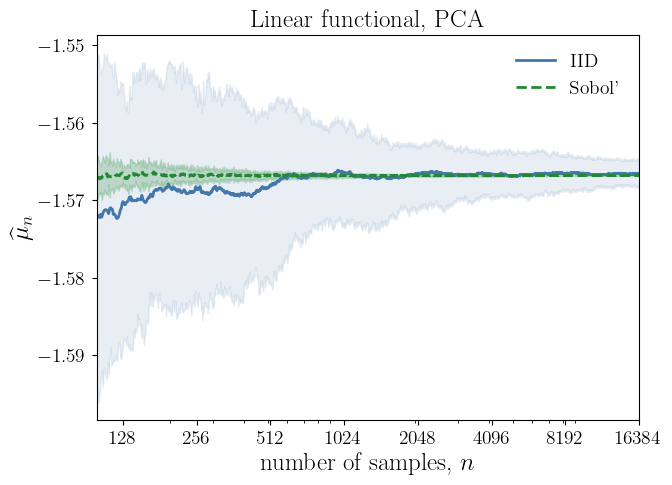

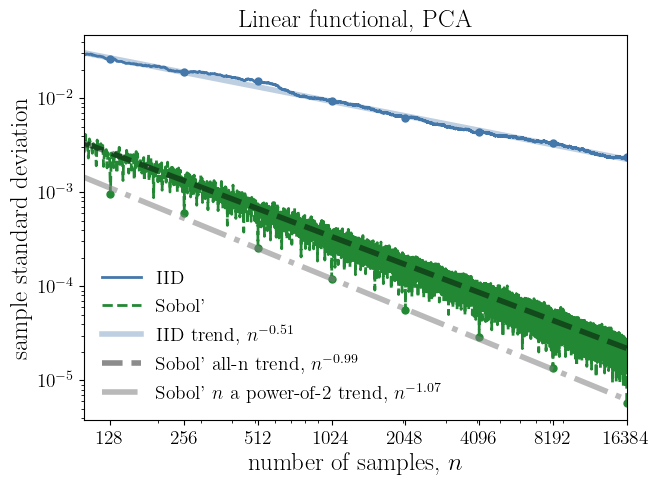

Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_pca_iid_sobol.md


,Sequence,PCA std($\widehat{\mu}_n$),PCA std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.002381,1.000000
1,Sobol',0.000006,0.002424


In [36]:
print("d =",d_grid)
running, payload = run_transform_simulations(
    integrand_key="linear_functional",
    transform_key="pca",
    n=n,
    reps=100,
    overwrite=True,
)

summary = plot_and_summarize_transform_benchmark(
    integrand_key=payload["integrand_key"],
    transform_key=payload["transform_key"],
    running=running,
    plot_sequence_keys=["iid", "sobol"],
)

display(summary)

## Run PCA benchmarks

In [37]:
integrand_key = "risk_qoi"
transform_key = "pca"

if run_sims:
    running, payload = run_transform_simulations(
        integrand_key,
        transform_key,
        n=n,
        reps=r,
        tag=None,
        timestamp=False,
    )

    benchmark_files[transform_key] = payload["path"]

    print(f"\nCurrent benchmark file for {integrand_key}, {transform_key} in:")
    print(benchmark_files[transform_key])

Saved benchmark for risk_qoi, pca data to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/benchmarks/running_risk_qoipca_n16384_reps100.pkl

Current benchmark file for risk_qoi, pca in:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/benchmarks/running_risk_qoipca_n16384_reps100.pkl


## Plot PCA benchmarks

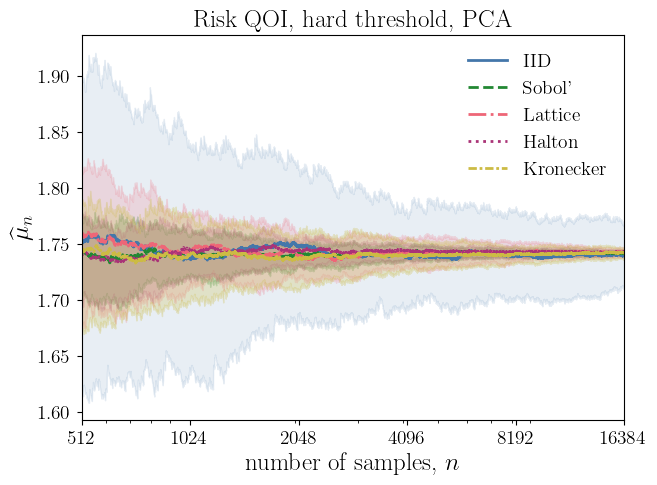

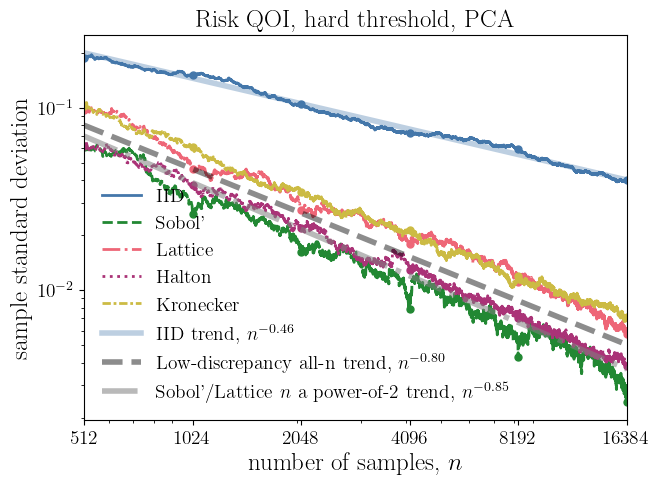

Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_pca_sequences.md


,Sequence,PCA std($\widehat{\mu}_n$),PCA std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.039943,1.000000
1,Sobol',0.002424,0.060694
2,Lattice,0.005747,0.143874
3,Halton,0.003859,0.096600
4,Kronecker,0.007165,0.179372


In [38]:
transform_key = "pca"
transform = transforms[transform_key]

payload = load_benchmark_payload(benchmark_files[transform_key])
running = payload["running"]

transforms[transform_key]["running"] = running
transforms[transform_key]["payload"] = payload

pca_summary = plot_and_summarize_transform_benchmark(
    integrand_key=integrand_key,
    transform_key=transform_key,
    running=running,
    n_min_plot=n_min_plt,
)

display(pca_summary)

## Plot IID & Sobol PCA benchmarks

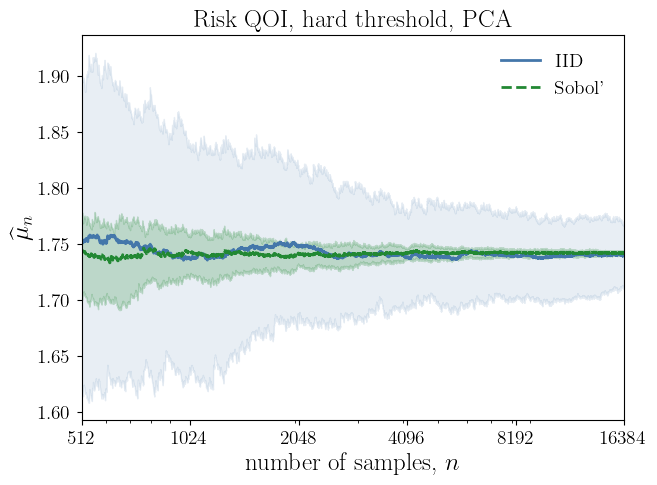

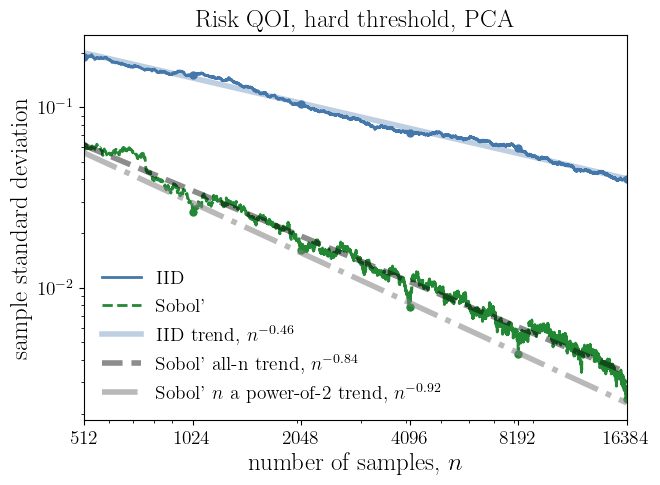

Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_pca_iid_sobol.md


,Sequence,PCA std($\widehat{\mu}_n$),PCA std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.039943,1.000000
1,Sobol',0.002424,0.060694


In [39]:
transform_key = "pca"

payload = load_benchmark_payload(benchmark_files[transform_key])
running = payload["running"]

transforms[transform_key]["running"] = running
transforms[transform_key]["payload"] = payload

iid_sob_pca_summary = plot_and_summarize_transform_benchmark(
    integrand_key=integrand_key,
    transform_key=transform_key,
    running=transforms[transform_key]["running"],
    plot_sequence_keys=["iid", "sobol"],
    n_min_plot=n_min_plt,
)

display(iid_sob_pca_summary)

## Run benchmarks for Cholesky

In [40]:
transform_key = "chol"

if run_sims:
    running, payload = run_transform_simulations(
        integrand_key,
        transform_key,
        n=n,
        reps=r,
        tag=None,
        timestamp=False,
    )

    benchmark_files[transform_key] = payload["path"]

    print(f"\nCurrent benchmark file for {transform_key}:")
    print(benchmark_files[transform_key])

Saved benchmark for risk_qoi, chol data to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/benchmarks/running_risk_qoichol_n16384_reps100.pkl

Current benchmark file for chol:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/benchmarks/running_risk_qoichol_n16384_reps100.pkl


## Plot Cholesky benchmarks

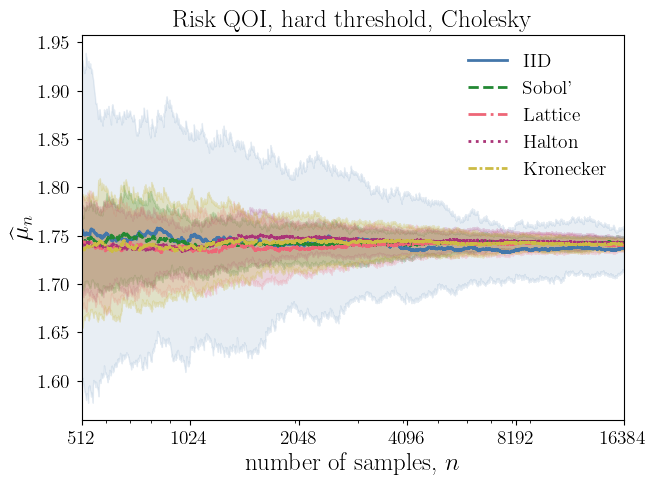

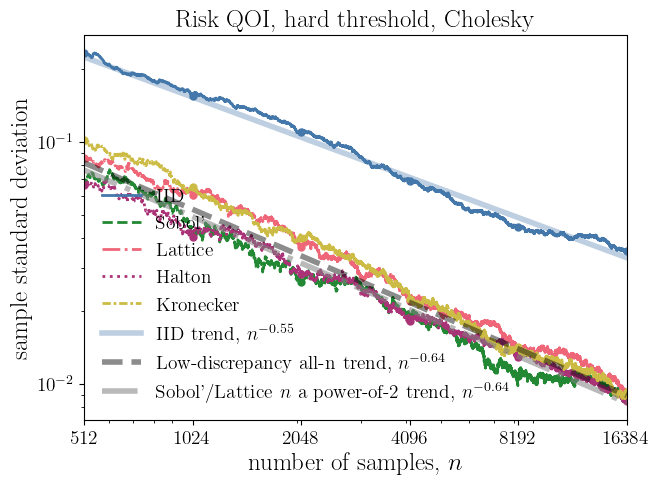

Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_chol_sequences.md


,Sequence,Cholesky std($\widehat{\mu}_n$),Cholesky std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.035327,1.000000
1,Sobol',0.008964,0.253757
2,Lattice,0.008780,0.248530
3,Halton,0.008519,0.241146
4,Kronecker,0.009229,0.261249


In [41]:
transform_key = "chol"

payload = load_benchmark_payload(benchmark_files[transform_key])
running = payload["running"]

transforms[transform_key]["running"] = running
transforms[transform_key]["payload"] = payload

chol_summary = plot_and_summarize_transform_benchmark(
    integrand_key=integrand_key,
    transform_key=transform_key,
    running=running,
    n_min_plot=n_min_plt,
)

display(chol_summary)

## Merge PCA & Cholesky table for all

In [42]:
sequence_order = [
    "IID",
    "Sobol'",
    "Lattice",
    "Halton",
    "Kronecker",
]

summary_all_pca_chol = pca_summary.merge(
    chol_summary,
    on="Sequence",
    how="outer",
)

summary_all_pca_chol["Sequence"] = pd.Categorical(
    summary_all_pca_chol["Sequence"],
    categories=sequence_order,
    ordered=True,
)

summary_all_pca_chol = summary_all_pca_chol.sort_values(
    "Sequence"
).reset_index(drop=True)

display(summary_all_pca_chol)

,Sequence,PCA std($\widehat{\mu}_n$),PCA std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$),Cholesky std($\widehat{\mu}_n$),Cholesky std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.039943,1.000000,0.035327,1.000000
1,Sobol',0.002424,0.060694,0.008964,0.253757
2,Lattice,0.005747,0.143874,0.008780,0.248530
3,Halton,0.003859,0.096600,0.008519,0.241146
4,Kronecker,0.007165,0.179372,0.009229,0.261249


## Plot IID & Sobol' Cholesky benchmarks

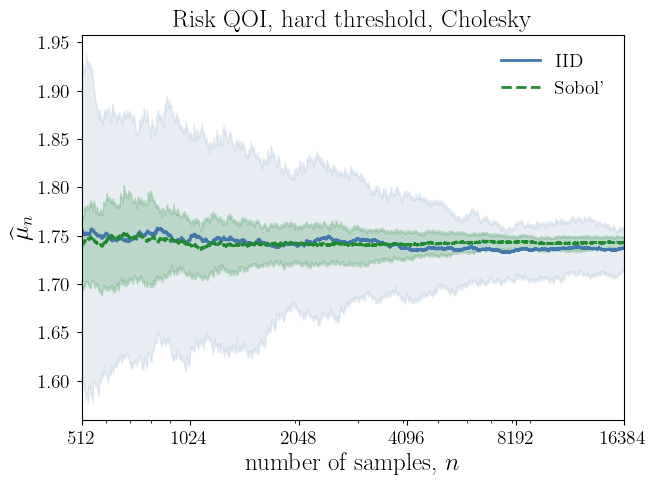

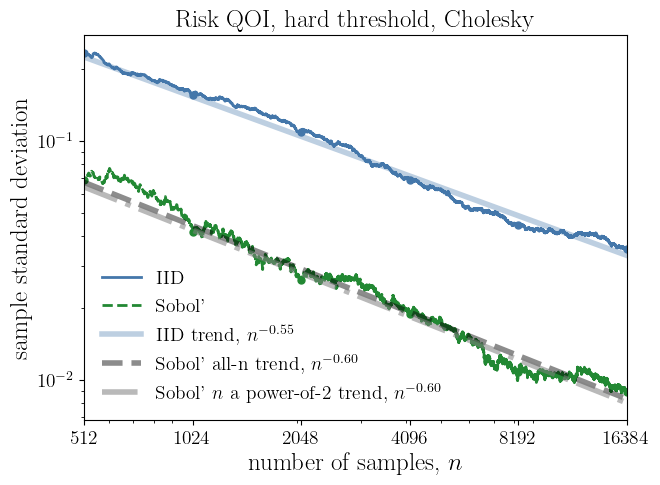

Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_chol_iid_sobol.md


,Sequence,Cholesky std($\widehat{\mu}_n$),Cholesky std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.035327,1.000000
1,Sobol',0.008964,0.253757


In [45]:
transform_key = "chol"

payload = load_benchmark_payload(benchmark_files[transform_key])
running = payload["running"]

transforms[transform_key]["running"] = running
transforms[transform_key]["payload"] = payload

iid_sob_chol_summary = plot_and_summarize_transform_benchmark(
    integrand_key=integrand_key,
    transform_key=transform_key,
    running=transforms[transform_key]["running"],
    plot_sequence_keys=["iid", "sobol"],
    n_min_plot=n_min_plt,
)

display(iid_sob_chol_summary)

## Merge PCA & Cholesky for IID and Sobol' 

In [46]:
sequence_order = [
    "IID",
    "Sobol'",
]

summary_iid_sob_pca_chol = iid_sob_pca_summary.merge(
    iid_sob_chol_summary,
    on="Sequence",
    how="outer",
)

summary_iid_sob_pca_chol["Sequence"] = pd.Categorical(
    summary_iid_sob_pca_chol["Sequence"],
    categories=sequence_order,
    ordered=True,
)

summary_iid_sob_pca_chol = summary_iid_sob_pca_chol.sort_values(
    "Sequence"
).reset_index(drop=True)

display(summary_iid_sob_pca_chol)

,Sequence,PCA std($\widehat{\mu}_n$),PCA std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$),Cholesky std($\widehat{\mu}_n$),Cholesky std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,IID,0.039943,1.000000,0.035327,1.000000
1,Sobol',0.002424,0.060694,0.008964,0.253757


# Simple test cases to explore possible $\Order(n^{-3/2})$ fast convergence

## Proposal factories

## Simple benchmark helpers

In [157]:
def gaussian_sample_and_weight(discrete_dist, d, n, reps, proposal_sd):
    proposal = qp.Gaussian(
        sampler=discrete_dist,
        mean=np.zeros(d),
        covariance=(proposal_sd**2) * np.eye(d),
    )

    x = proposal(n)

    if x.ndim == 2:
        x = x.reshape(1, *x.shape)

    r_actual, n_actual, d_actual = x.shape
    assert d_actual == d

    x_flat = x.reshape(r_actual * n_actual, d)

    norm2 = np.sum(x_flat**2, axis=1)

    weight = (proposal_sd**d) * np.exp(
        -0.5 * (1 - 1 / proposal_sd**2) * norm2
    )

    vals = (norm2/d) * weight

    return vals.reshape(r_actual, n_actual)

def logistic_sample_and_weight(discrete_dist, d, n, reps, proposal_sd):
    scale = proposal_sd * np.sqrt(3) / np.pi

    u = discrete_dist(n)

    if u.ndim == 2:
        u = u.reshape(1, *u.shape)

    r_actual, n_actual, d_actual = u.shape
    assert d_actual == d

    u_flat = u.reshape(r_actual * n_actual, d)
    u_flat = np.clip(u_flat, 1e-15, 1 - 1e-15)

    x_flat = scale * np.log(u_flat / (1 - u_flat))

    norm2 = np.sum(x_flat**2, axis=1)

    log_target = (
        -0.5 * d * np.log(2 * np.pi)
        -0.5 * norm2
    )

    z = x_flat / scale

    log_q_1d = (
        -np.log(scale)
        - z
        - 2 * np.logaddexp(0, -z)
    )

    log_q = np.sum(log_q_1d, axis=1)

    weight = np.exp(log_target - log_q)

    vals = (norm2/d) * weight

    return vals.reshape(r_actual, n_actual)

def polynomial_uniform_sample(discrete_dist, d, n, reps):
    u = discrete_dist(n)

    if u.ndim == 2:
        u = u.reshape(1, *u.shape)

    r_actual, n_actual, d_actual = u.shape
    assert d_actual == d

    u_flat = u.reshape(r_actual * n_actual, d)

    vals = np.mean(3 * u_flat**2, axis=1)

    return vals.reshape(r_actual, n_actual)

In [158]:
def replicate_running_means_simple(
    sequence,
    proposal_family,
    d,
    proposal_sd,
    n,
    reps=r,
):
    discrete_dist = sequence["distribution"](
        reps=reps,
        dimension=d,
    )

    if proposal_family == "Gaussian":
        vals = gaussian_sample_and_weight(
            discrete_dist=discrete_dist,
            d=d,
            n=n,
            reps=reps,
            proposal_sd=proposal_sd,
        )

    elif proposal_family == "logistic":
        vals = logistic_sample_and_weight(
            discrete_dist=discrete_dist,
            d=d,
            n=n,
            reps=reps,
            proposal_sd=proposal_sd,
        )

    elif proposal_family == "uniform_poly":
        vals = polynomial_uniform_sample(
            discrete_dist=discrete_dist,
            d=d,
            n=n,
            reps=reps,
        )

    else:
        raise ValueError(f"Unknown proposal_family: {proposal_family}")

    return np.cumsum(vals, axis=1) / np.arange(1, vals.shape[1] + 1)


def run_simple_importance_case(
    d,
    proposal_family,
    proposal_sd,
    n,
    reps=r,
    sequences=sequences,
):
    running = {}

    for key, sequence in sequences.items():
        running[key] = replicate_running_means_simple(
            sequence=sequence,
            proposal_family=proposal_family,
            d=d,
            proposal_sd=proposal_sd,
            n=n,
            reps=reps,
        )

    return running


def simple_case_label(proposal_family, proposal_sd, d):
    if proposal_family == "uniform_poly":
        return rf"Uniform target, $f(\boldsymbol{{x}})=3\lVert \boldsymbol{{x}}\rVert^2/d, \; d={d}, \quad \mu = 1$"

    if proposal_family == "Gaussian" and proposal_sd == 1.0:
        return rf"Gaussian target, $f(\boldsymbol{{x}})=\lVert\boldsymbol{{x}}\rVert^2/d, \; d={d}, \quad \mu = 1$"

    return f"{proposal_family.capitalize()}, SD={proposal_sd:.3g}, d={d}"


def summarize_running_simple(
    running,
    sequences,
    d,
    proposal_family,
    proposal_sd,
    n_min_plot=100,
):
    exact_mean = 1.0
    iid_sd = running["iid"][:, -1].std(ddof=1)

    rows = []

    for key, sequence in sequences.items():
        slopes = compute_sd_slopes(
            running=running[key],
            exact_mean=exact_mean,
            n_min=n_min_plot,
        )

        final_sd = slopes["sd_by_n"][-1]

        row = {
            "dimension": d,
            "sequence": sequence["label"],
            "slope_all": slopes["slope_all"],
            "slope_pow2": slopes["slope_pow2"],
            "final_sd": final_sd,
            "relative_sd": final_sd / iid_sd,
        }       
        if proposal_family != "uniform_poly":
            row = {
                "dimension": d,
                "proposal_family": proposal_family,
                "proposal_sd": proposal_sd,
                "sequence": sequence["label"],
                "slope_all": slopes["slope_all"],
                "slope_pow2": slopes["slope_pow2"],
                "final_sd": final_sd,
                "relative_sd": final_sd / iid_sd,
            }
        
        rows.append(row)
        
    return pd.DataFrame(rows)

def simple_case_savefig_suffix(proposal_family, proposal_sd, d):
    if proposal_family == "uniform_poly":
        return f"uniform_poly_d{d}"

    sd_label = f"{proposal_sd:.3g}".replace(".", "p")
    return f"{proposal_family}_sd{sd_label}_d{d}"

def plot_and_summarize_simple_case(
    d,
    proposal_family,
    proposal_sd,
    n,
    reps=r,
    sequences=sequences,
    n_min_plot=100,
    fill_hw=fill_hw_default,
    make_running_plot=True,
    make_sd_plot=True,
):
    running = run_simple_importance_case(
        d=d,
        proposal_family=proposal_family,
        proposal_sd=proposal_sd,
        n=n,
        reps=reps,
        sequences=sequences,
    )

    title = simple_case_label(
        proposal_family=proposal_family,
        proposal_sd=proposal_sd,
        d=d,
    )

    savefig_suffix = simple_case_savefig_suffix(
        proposal_family=proposal_family,
        proposal_sd=proposal_sd,
        d=d,
    )

    if make_running_plot:
        plot_running_sequences(
            running=running,
            sequences=sequences,
            title=title,
            ylabel=r"$\widehat{\mu}_n$",
            n_min_plot=n_min_plot,
            fill_hw=fill_hw,
            savefig=f"simple_running_{savefig_suffix}",
        )

    if make_sd_plot:
        plot_running_sd_vs_n(
            running=running,
            sequences=sequences,
            title=title,
            ylabel=r"std$(\widehat{\mu}_n)$ across randomizations",
            n_min_plot=n_min_plot,
            trend_n_min=n_min_plot,
            savefig=f"simple_sd_{savefig_suffix}",
        )

    summary = summarize_running_simple(
        running=running,
        sequences=sequences,
        d=d,
        proposal_family=proposal_family,
        proposal_sd=proposal_sd,
        n_min_plot=n_min_plot,
    )

    return running, summary

DISPLAY_COLUMNS = {
    "dimension": "$d$",
    "sequence": "Sequence",
    "slope_all": "All-$n$ slope",
    "slope_pow2": "$n=2^m$ slope",
    "final_sd": r"std($\widehat{\mu}_n$)",
    "relative_sd": r"std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)",
    "proposal_family": "Proposal",
    "proposal_sd": r"Proposal $\sigma$",
    "case": "Case",
}

def make_table_key(
    benchmark_name,
    d_array,
    sequence_suffix="iid_sobol",
):
    d_suffix = "_".join(f"d{d}" for d in d_array)
    return f"{benchmark_name}_{d_suffix}_{sequence_suffix}"
    
def write_simple_summary_table(
    summary,
    table_key,
    n=None,
):
    filename = f"summary_simple_{table_key}.md"

    summary_display = summary.rename(columns=DISPLAY_COLUMNS)

    summary_md = summary_display.to_markdown(
        index=False,
        floatfmt=".3g",
    )

    header = ""
    if n is not None:
        header = (
            "<div style='text-align:center;'>"
            rf"<em>For $n = {n}$</em>"
            "</div>\n"
        )

    full_md = header + summary_md + "\n"

    path = CACHE_TABLE_DIR / filename
    path.write_text(full_md)

    print(f"Saved table to:\n{path}")

    return path


## Only IID and Sobol'

In [159]:
test_sequences = {
    key: sequences[key]
    for key in ["iid", "sobol"]
}

## Integral of norm squared wrt uniform

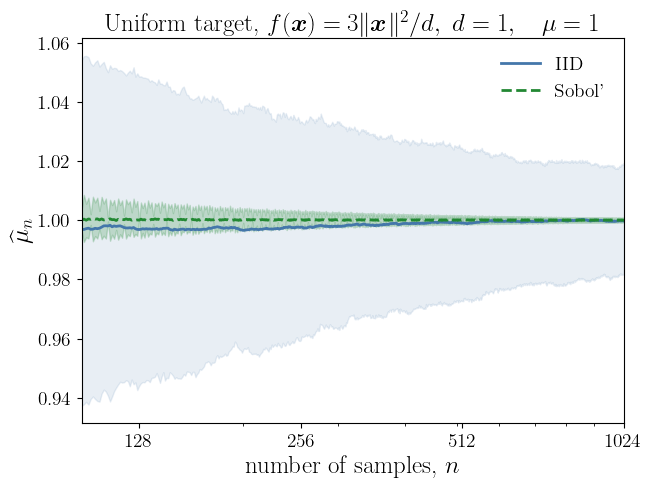

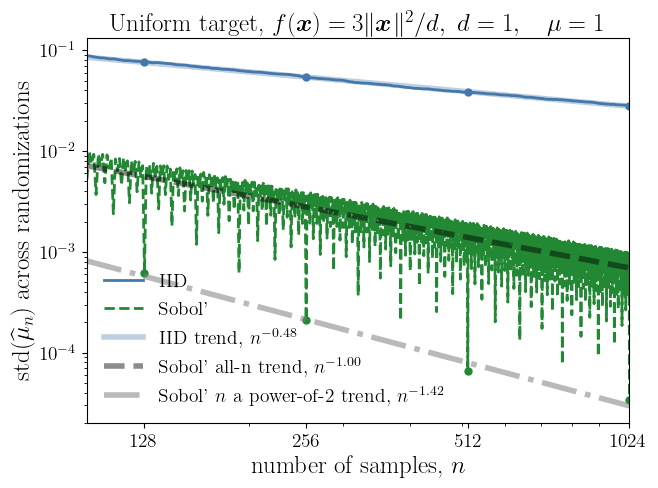

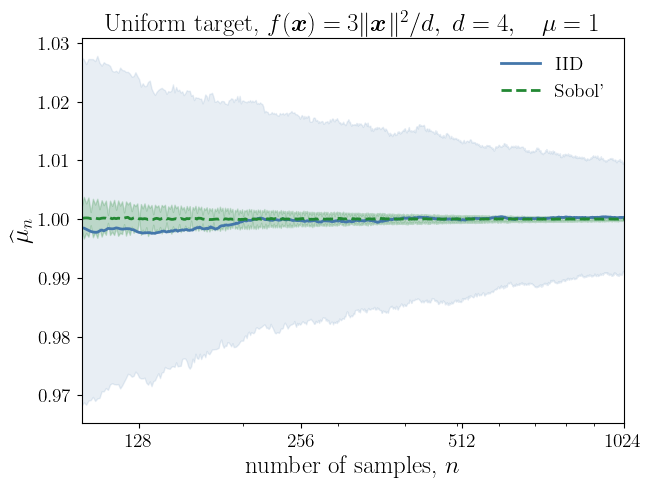

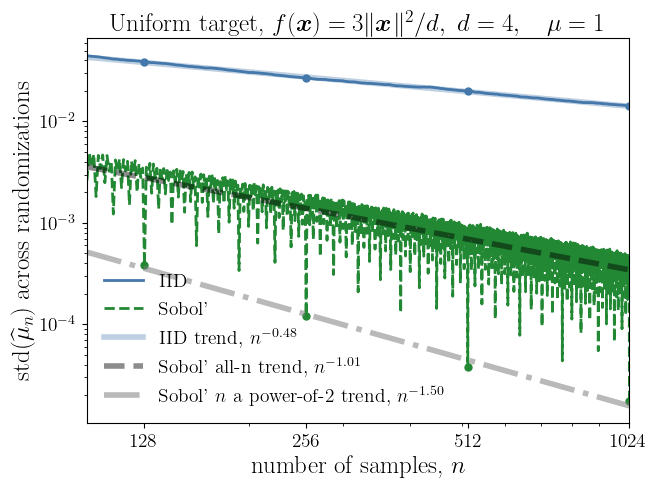

,$d$,Sequence,All-$n$ slope,$n=2^m$ slope,std($\widehat{\mu}_n$),std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,1,IID,-0.481442,-0.482178,0.028174,1.000000
1,1,Sobol',-1.004180,-1.423261,0.000034,0.001211
2,4,IID,-0.477871,-0.479841,0.014142,1.000000
3,4,Sobol',-1.005866,-1.499882,0.000018,0.001242


Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_simple_uniform_norm_sq_d1_d4_iid_sobol.md


PosixPath('/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_simple_uniform_norm_sq_d1_d4_iid_sobol.md')

In [170]:
uniform_poly_summaries = {}

n = 2**10
d_array = [1, 64]

for d in d_array:
    running, summary = plot_and_summarize_simple_case(
        d=d,
        proposal_family="uniform_poly",
        proposal_sd=None,
        n=n,
        reps=1000,
        sequences=test_sequences,
        n_min_plot=100,
    )

    uniform_poly_summaries[d] = summary

uniform_poly_summary = pd.concat(
    uniform_poly_summaries.values(),
    ignore_index=True,
).sort_values(
    ["dimension", "sequence"]
).reset_index(drop=True)

display(uniform_poly_summary.rename(columns=DISPLAY_COLUMNS))

# markdown output
d_suffix = "_".join(f"d{d}" for d in d_array)

table_key = make_table_key(
    benchmark_name="uniform_norm_sq",
    d_array=d_array,
)

write_simple_summary_table(
    uniform_poly_summary,
    table_key=table_key,
    n=n,
)

## Integral of norm squared wrt Gaussian

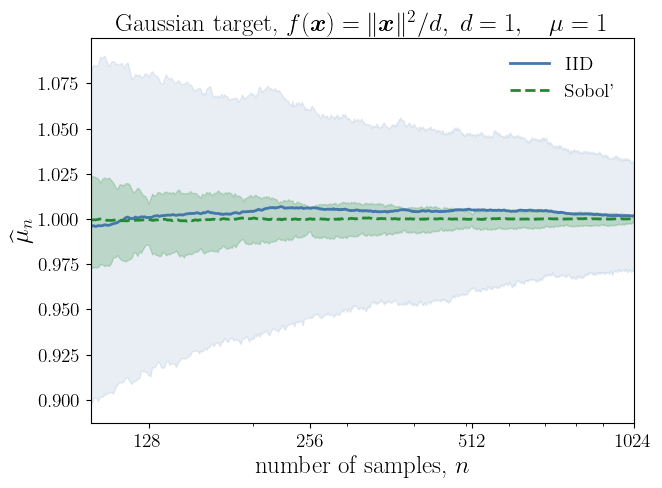

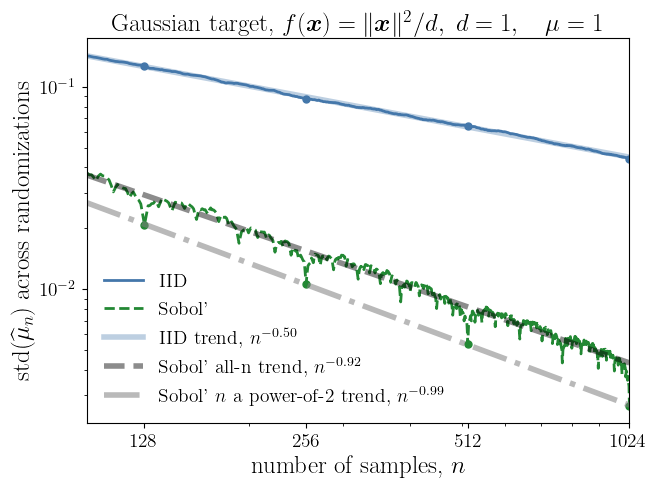

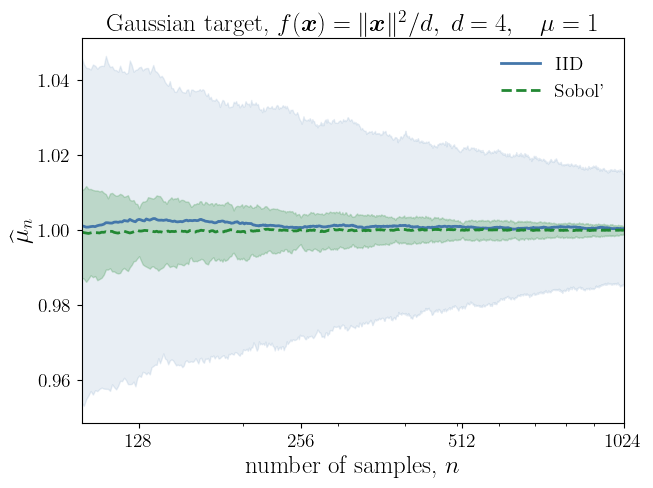

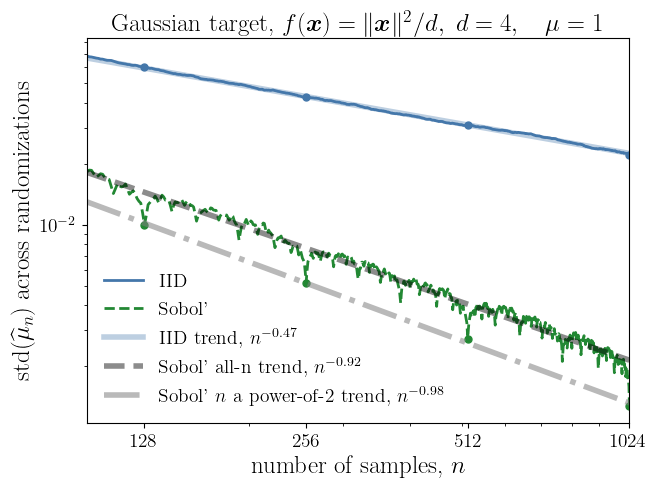

,$d$,Proposal,Proposal SD,Sequence,All-$n$ slope,$n=2^m$ slope,std($\widehat{\mu}_n$),std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,1,Gaussian,1.0,IID,-0.495366,-0.498032,0.044258,1.000000
1,1,Gaussian,1.0,Sobol',-0.918537,-0.989607,0.002654,0.059972
2,4,Gaussian,1.0,IID,-0.466735,-0.477763,0.022128,1.000000
3,4,Gaussian,1.0,Sobol',-0.919169,-0.984134,0.001271,0.057437


Saved table to:
/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_simple_gaussian_norm_sq_d1_d4_iid_sobol.md


PosixPath('/Users/fredjhickernell/SoftwareRepositories/MCQMC26/notebooks/cache/tables/summary_simple_gaussian_norm_sq_d1_d4_iid_sobol.md')

In [177]:
gaussian_summaries = {}

n = 2**10

d_array = [1, 4]

for d in d_array:
    running, summary = plot_and_summarize_simple_case(
        d=d,
        proposal_family="Gaussian",
        proposal_sd=1.0,
        n=n,
        reps=1000,
        sequences=test_sequences,
        n_min_plot=100,
    )

    gaussian_summaries[d] = summary

gaussian_summary = pd.concat(
    gaussian_summaries.values(),
    ignore_index=True,
).sort_values(["dimension", "sequence"]).reset_index(drop=True)

display(gaussian_summary.rename(columns=DISPLAY_COLUMNS))

table_key = make_table_key(
    benchmark_name="gaussian_norm_sq",
    d_array=d_array,
)

# markdown output
write_simple_summary_table(
    gaussian_summary,
    table_key=table_key,
    n=n,
)

## Try Importance Sampling

In [178]:
dimensions = [1, 4]

proposal_grid = [
    ("Gaussian", 1.0),
    ("Gaussian", 1.5),
    ("Gaussian", 2.00),
    ("Gaussian", 4.00),
    ("logistic", 1.00),
    ("logistic", 1.5),
    ("logistic", 2.00),
    ("logistic", 4.00),
]

n = 2**10
reps = 1000
n_min_plot = 100

all_simple_running = {}
all_simple_summaries = []

for d in dimensions:
    for proposal_family, proposal_sd in proposal_grid:
        running, summary = plot_and_summarize_simple_case(
            d=d,
            proposal_family=proposal_family,
            proposal_sd=proposal_sd,
            n=n,
            reps=reps,
            sequences=test_sequences,
            n_min_plot=n_min_plot,
            make_running_plot=False,
            make_sd_plot=False,
        )

        all_simple_running[(d, proposal_family, proposal_sd)] = running
        all_simple_summaries.append(summary)

simple_summary = (
    pd.concat(
        all_simple_summaries,
        ignore_index=True,
    )
    .sort_values(
        [
            "dimension",
            "proposal_family",
            "proposal_sd",
            "sequence",
        ]
    )
    .reset_index(drop=True)
)

display(simple_summary)

,dimension,proposal_family,proposal_sd,sequence,slope_all,slope_pow2,final_sd,relative_sd
0,1,Gaussian,1.0,IID,-0.503916,-0.507515,0.042969,1.000000
1,1,Gaussian,1.0,Sobol',-0.935646,-0.992905,0.002519,0.058623
2,1,Gaussian,1.5,IID,-0.521025,-0.513541,0.021068,1.000000
3,1,Gaussian,1.5,Sobol',-1.003137,-1.525011,0.000116,0.005529
4,1,Gaussian,2.0,IID,-0.500378,-0.502029,0.021804,1.000000
5,1,Gaussian,2.0,Sobol',-1.003075,-1.329744,0.000099,0.004530
6,1,Gaussian,4.0,IID,-0.496224,-0.484346,0.035540,1.000000
7,1,Gaussian,4.0,Sobol',-1.010404,-1.797930,0.000093,0.002612
8,1,logistic,1.0,IID,-0.499549,-0.495052,0.045648,1.000000
9,1,logistic,1.0,Sobol',-0.996939,-1.265089,0.001210,0.026511


In [179]:
display(
    simple_summary.pivot_table(
        index=["dimension", "proposal_family", "proposal_sd"],
        columns="sequence",
        values=["slope_all", "slope_pow2"],
    )
)

slope_all           slope_pow2          
sequence                                    IID    Sobol'        IID    Sobol'
dimension proposal_family proposal_sd                                         
1         Gaussian        1.0         -0.503916 -0.935646  -0.507515 -0.992905
                          1.5         -0.521025 -1.003137  -0.513541 -1.525011
                          2.0         -0.500378 -1.003075  -0.502029 -1.329744
                          4.0         -0.496224 -1.010404  -0.484346 -1.797930
          logistic        1.0         -0.499549 -0.996939  -0.495052 -1.265089
                          1.5         -0.495293 -0.999933  -0.498912 -1.398282
                          2.0         -0.492956 -1.007498  -0.493459 -1.505953
                          4.0         -0.503581 -1.006348  -0.491769 -1.482029
4         Gaussian        1.0         -0.476139 -0.920461  -0.483528 -0.997249
                          1.5         -0.519585 -0.916164  -0.505902 -1.065677
                          2.0         -0.504630 -0.830757  -0.513339 -0.914335
                          4.0         -0.476124 -0.862472  -0.478880 -0.961293
          logistic        1.0         -0.466876 -0.832621  -0.472814 -0.875589
                          1.5         -0.498173 -0.914915  -0.494932 -1.004521
                          2.0         -0.508714 -0.880179  -0.510782 -0.969249
                          4.0         -0.490855 -0.890230  -0.491853 -0.971249

In [180]:
sobol_summary = simple_summary[
    simple_summary["sequence"] == "Sobol'"
].copy()

display(
    sobol_summary.sort_values(
        ["dimension", "slope_pow2"],
        ascending=[True, True],
    )
)

,dimension,proposal_family,proposal_sd,sequence,slope_all,slope_pow2,final_sd,relative_sd
7,1,Gaussian,4.0,Sobol',-1.010404,-1.797930,0.000093,0.002612
3,1,Gaussian,1.5,Sobol',-1.003137,-1.525011,0.000116,0.005529
13,1,logistic,2.0,Sobol',-1.007498,-1.505953,0.000093,0.004071
15,1,logistic,4.0,Sobol',-1.006348,-1.482029,0.000142,0.004291
11,1,logistic,1.5,Sobol',-0.999933,-1.398282,0.000164,0.006376
5,1,Gaussian,2.0,Sobol',-1.003075,-1.329744,0.000099,0.004530
9,1,logistic,1.0,Sobol',-0.996939,-1.265089,0.001210,0.026511
1,1,Gaussian,1.0,Sobol',-0.935646,-0.992905,0.002519,0.058623
19,4,Gaussian,1.5,Sobol',-0.916164,-1.065677,0.002108,0.127234
27,4,logistic,1.5,Sobol',-0.914915,-1.004521,0.002112,0.129861


,$d$,Proposal,Proposal SD,Sequence,All-$n$ slope,$n=2^m$ slope,std($\widehat{\mu}_n$),std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$)
0,1,Gaussian,4.0,Sobol',-1.010404,-1.797930,0.000093,0.002612
1,4,Gaussian,1.5,Sobol',-0.916164,-1.065677,0.002108,0.127234


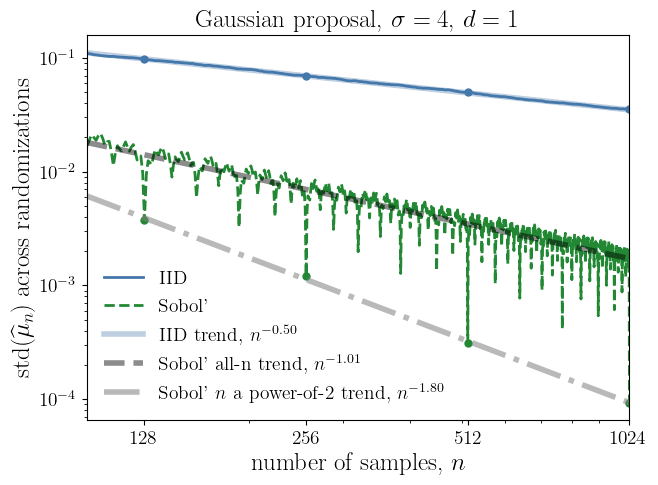

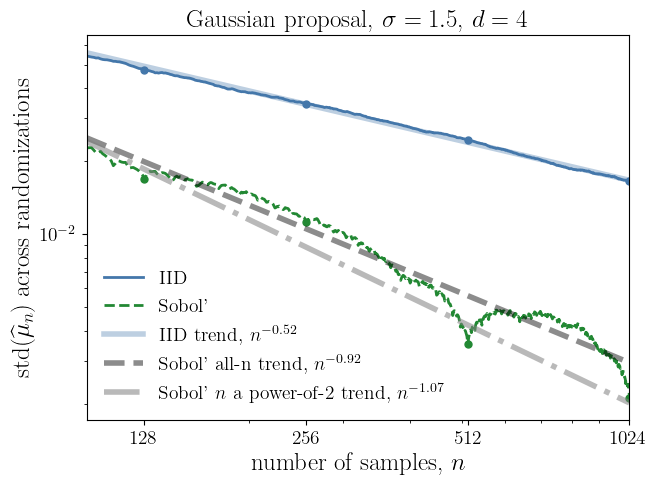

In [181]:
best_by_d = sobol_summary.loc[
    sobol_summary.groupby("dimension")["slope_pow2"].idxmin()
].sort_values("dimension").reset_index(drop=True)

display(best_by_d.rename(columns=DISPLAY_COLUMNS))

for _, best in best_by_d.iterrows():
    d_best = int(best["dimension"])
    proposal_family_best = best["proposal_family"]
    proposal_sd_best = float(best["proposal_sd"])

    running_best = all_simple_running[
        (d_best, proposal_family_best, proposal_sd_best)
    ]

    plot_running_sd_vs_n(
        running=running_best,
        sequences=test_sequences,
        title=(
            f"{proposal_family_best} proposal, "
            rf"$\sigma={proposal_sd_best:.3g}$, "
            rf"$d={d_best}$"
        ),
        ylabel=r"std$(\widehat{\mu}_n)$ across randomizations",
        n_min_plot=n_min_plot,
    )

In [188]:
gaussian_for_compare = gaussian_summary.copy()
best_is_for_compare = best_by_d.copy()

gaussian_for_compare["case"] = "Vanilla Gaussian"
best_is_for_compare["case"] = "Best IS"

comparison_table = pd.concat(
    [gaussian_for_compare, best_is_for_compare],
    ignore_index=True,
)

comparison_table["case"] = pd.Categorical(
    comparison_table["case"],
    categories=["Vanilla Gaussian", "Best IS"],
    ordered=True,
)

comparison_table = comparison_table.sort_values(
    ["dimension", "case", "sequence"]
).reset_index(drop=True)

display(
    comparison_table.rename(columns=DISPLAY_COLUMNS)
)

write_simple_summary_table(
    comparison_table,
    table_key=make_table_key(
        benchmark_name="vanilla_gaussian_vs_best_is",
        d_array=d_array,
    ),
    n=n,
)

,$d$,Proposal,Proposal SD,Sequence,All-$n$ slope,$n=2^m$ slope,std($\widehat{\mu}_n$),std($\widehat{\mu}_n$) / IID std($\widehat{\mu}_n$),case
0,1,Gaussian,1.0,IID,-0.495366,-0.498032,0.044258,1.000000,Vanilla Gaussian
1,1,Gaussian,1.0,Sobol',-0.918537,-0.989607,0.002654,0.059972,Vanilla Gaussian
2,1,Gaussian,4.0,Sobol',-1.010404,-1.797930,0.000093,0.002612,Best IS
3,4,Gaussian,1.0,IID,-0.466735,-0.477763,0.022128,1.000000,Vanilla Gaussian
4,4,Gaussian,1.0,Sobol',-0.919169,-0.984134,0.001271,0.057437,Vanilla Gaussian
5,4,Gaussian,1.5,Sobol',-0.916164,-1.065677,0.002108,0.127234,Best IS
